In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,confusion_matrix,mean_absolute_error,root_mean_squared_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import optuna
from sklearn.pipeline import Pipeline

import joblib
import os

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('data/studs.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X = df.drop(columns=['math score'])
y = df['math score']

### COLUMN TRANSFORMER

In [5]:
num_features = [col for col in X if X[col].dtype == 'float64' or X[col].dtype == 'int64']
cat_features = [col for col in X if col not in num_features]

In [6]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [7]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",cat_transformer,cat_features),
        ("StandardScaler",num_transformer,num_features)
    ]
)

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [10]:
list_models = {
    "Linear Regression": {
        "model": LinearRegression,
        "params": {}
    },
    "Ridge": {
        "model": Ridge,
        "params": {
            "alpha": {
                "suggest": "float",
                "low": 1e-4,
                "high": 100,
                "log": True
            }
        }
    },
    "Lasso": {
        "model": Lasso,
        "params": {
            "alpha": {
                "suggest": "float",
                "low": 1e-4,
                "high": 10,
                "log": True
            }
        }
    },
    "ElasticNet": {
        "model": ElasticNet,
        "params": {
            "alpha": {
                "suggest": "float",
                "low": 1e-4,
                "high": 10,
                "log": True
            },
            "l1_ratio": {
                "suggest": "float",
                "low": 0.0,
                "high": 1.0
            }
        }
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor,
        "params": {
            "criterion": {
                "suggest": "categorical",
                "choices": ["squared_error", "friedman_mse", "absolute_error"]
            },
            "max_depth": {
                "suggest": "int",
                "low": 2,
                "high": 30
            },
            "min_samples_split": {
                "suggest": "int",
                "low": 2,
                "high": 20
            },
            "min_samples_leaf": {
                "suggest": "int",
                "low": 1,
                "high": 10
            }
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor,
        "params": {
            "n_estimators": {
                "suggest": "int",
                "low": 100,
                "high": 500
            },
            "max_depth": {
                "suggest": "int",
                "low": 3,
                "high": 30
            },
            "min_samples_split": {
                "suggest": "int",
                "low": 2,
                "high": 20
            },
            "min_samples_leaf": {
                "suggest": "int",
                "low": 1,
                "high": 10
            },
            "max_features": {
                "suggest": "categorical",
                "choices": ["sqrt", "log2", None]
            }
        }
    },
    "KNN": {
        "model": KNeighborsRegressor,
        "params": {
            "n_neighbors": {
                "suggest": "int",
                "low": 2,
                "high": 30
            },
            "weights": {
                "suggest": "categorical",
                "choices": ["uniform", "distance"]
            },
            "p": {
                "suggest": "int",
                "low": 1,
                "high": 2
            }
        }
    },
    "SVR": {
        "model": SVR,
        "params": {
            "C": {
                "suggest": "float",
                "low": 1e-2,
                "high": 100,
                "log": True
            },
            "epsilon": {
                "suggest": "float",
                "low": 1e-3,
                "high": 1.0,
                "log": True
            },
            "kernel": {
                "suggest": "categorical",
                "choices": ["linear", "rbf", "poly"]
            },
            "gamma": {
                "suggest": "categorical",
                "choices": ["scale", "auto"]
            }
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor,
        "params": {
            "n_estimators": {
                "suggest": "int",
                "low": 50,
                "high": 500
            },
            "learning_rate": {
                "suggest": "float",
                "low": 1e-3,
                "high": 1.0,
                "log": True
            },
            "loss": {
                "suggest": "categorical",
                "choices": ["linear", "square", "exponential"]
            }
        }
    },
    "XGBoost": {
        "model": XGBRegressor,
        "params": {
            "n_estimators": {
                "suggest": "int",
                "low": 100,
                "high": 500
            },
            "learning_rate": {
                "suggest": "float",
                "low": 1e-3,
                "high": 0.3,
                "log": True
            },
            "max_depth": {
                "suggest": "int",
                "low": 3,
                "high": 12
            },
            "subsample": {
                "suggest": "float",
                "low": 0.5,
                "high": 1.0
            },
            "colsample_bytree": {
                "suggest": "float",
                "low": 0.5,
                "high": 1.0
            },
            "gamma": {
                "suggest": "float",
                "low": 0,
                "high": 5
            }
        }
    },
    "CatBoost": {
        "model": CatBoostRegressor,
        "params": {
            "iterations": {
                "suggest": "int",
                "low": 100,
                "high": 500
            },
            "learning_rate": {
                "suggest": "float",
                "low": 1e-3,
                "high": 0.3,
                "log": True
            },
            "depth": {
                "suggest": "int",
                "low": 4,
                "high": 10
            },
            "l2_leaf_reg": {
                "suggest": "float",
                "low": 1,
                "high": 10
            }
        }
    }
}

In [11]:
def build_params(trial, param_config):
    """
    Builds the hyperparameter dictionary using the
    configuration provided in list_models.
    """
    params = {}
    for param_name, config in param_config.items():
        suggest_method = getattr(
            trial,
            f"suggest_{config['suggest']}"
        )
        kwargs = {
            key: value
            for key, value in config.items()
            if key != "suggest"
        }
        params[param_name] = suggest_method(
            param_name,
            **kwargs
        )
    return params

def create_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

def finetuning(list_models,X_train,y_train,X_val,y_val,n_trials=50):
    results = {}
    for model_name, config in list_models.items():
        print(f"\nTuning {model_name}...")
        def objective(trial):
            params = build_params(trial,config["params"])
            # Some models need special arguments
            if model_name == "CatBoost":
                model = config["model"](
                    **params,
                    verbose=0,
                    random_state=42
                )
            elif model_name == "XGBoost":
                model = config["model"](**params,random_state=42,verbosity=0)
            else:
                model = config["model"](**params)
            pipeline = create_pipeline(model)
            pipeline.fit(
                X_train,
                y_train
            )
            prediction = pipeline.predict(
                X_val
            )
            rmse = root_mean_squared_error(y_val,prediction)
            return rmse
        study = optuna.create_study(
            direction="minimize"
        )
        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=True
        )
        ##################################################
        best_params = study.best_params
        if model_name == "CatBoost":

            best_model = config["model"](
                **best_params,
                verbose=0,
                random_state=42
            )
        elif model_name == "XGBoost":

            best_model = config["model"](
                **best_params,
                verbosity=0,
                random_state=42
            )
        else:

            best_model = config["model"](
                **best_params
            )
        best_pipeline = create_pipeline(best_model)
        best_pipeline.fit(
            X_train,
            y_train
        )
        prediction = best_pipeline.predict(
            X_val
        )

        ##################################################

        results[model_name] = {

            "Best RMSE": root_mean_squared_error(y_val,prediction),
            "Best R2": r2_score(y_val,prediction),
            "Best Parameters": best_params,
            "Pipeline": best_pipeline,
            "Study": study
        }

    return results

In [12]:
results = finetuning(list_models,X_train,y_train,X_val,y_val,n_trials=100)

[I 2026-06-30 15:02:46,829] A new study created in memory with name: no-name-2f295b86-d8ca-49f3-b902-7e100e362ea9



Tuning Linear Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-30 15:02:46,862] Trial 0 finished with value: 5.450242518083694 and parameters: {}. Best is trial 0 with value: 5.450242518083694.
[I 2026-06-30 15:02:46,874] Trial 1 finished with value: 5.450242518083694 and parameters: {}. Best is trial 0 with value: 5.450242518083694.
[I 2026-06-30 15:02:46,881] Trial 2 finished with value: 5.450242518083694 and parameters: {}. Best is trial 0 with value: 5.450242518083694.
[I 2026-06-30 15:02:46,887] Trial 3 finished with value: 5.450242518083694 and parameters: {}. Best is trial 0 with value: 5.450242518083694.
[I 2026-06-30 15:02:46,894] Trial 4 finished with value: 5.450242518083694 and parameters: {}. Best is trial 0 with value: 5.450242518083694.
[I 2026-06-30 15:02:46,906] Trial 5 finished with value: 5.450242518083694 and parameters: {}. Best is trial 0 with value: 5.450242518083694.
[I 2026-06-30 15:02:46,915] Trial 6 finished with value: 5.450242518083694 and parameters: {}. Best is trial 0 with value: 5.450242518083694.
[I 202

[I 2026-06-30 15:02:47,597] A new study created in memory with name: no-name-07bdab88-6ce2-435e-a3d3-f8d25e0f8c0a


...

[I 2026-06-30 15:03:23,052] Trial 0 finished with value: 6.304274559020996 and parameters: {'n_estimators': 115, 'learning_rate': 0.019212424544324945, 'max_depth': 3, 'subsample': 0.6530796105799854, 'colsample_bytree': 0.7265425109367675, 'gamma': 2.5829283953831883}. Best is trial 0 with value: 6.304274559020996.
[I 2026-06-30 15:03:23,227] Trial 1 finished with value: 8.64412784576416 and parameters: {'n_estimators': 111, 'learning_rate': 0.007313097739101616, 'max_depth': 7, 'subsample': 0.9785156213207904, 'colsample_bytree': 0.7067464590737571, 'gamma': 3.8894703130279824}. Best is trial 0 with value: 6.304274559020996.
[I 2026-06-30 15:03:23,554] Trial 2 finished with value: 6.024209499359131 and parameters: {'n_estimators': 155, 'learning_rate': 0.03839177690521373, 'max_depth': 9, 'subsample': 0.5239307413901235, 'colsample_bytree': 0.8406317678082944, 'gamma': 0.5680617848045216}. Best is trial 2 with value: 6.024209499359131.
[I 2026-06-30 15:03:23,914] Trial 3 finished wit

[I 2026-06-30 15:03:58,188] A new study created in memory with name: no-name-d0aba9e9-474c-494a-acca-8b3ecaa2220e



Tuning CatBoost...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-30 15:03:58,490] Trial 0 finished with value: 6.04983607295704 and parameters: {'iterations': 350, 'learning_rate': 0.007183203863111861, 'depth': 8, 'l2_leaf_reg': 1.137038349772346}. Best is trial 0 with value: 6.04983607295704.
[I 2026-06-30 15:03:59,123] Trial 1 finished with value: 6.09067484494735 and parameters: {'iterations': 380, 'learning_rate': 0.2432496742140186, 'depth': 10, 'l2_leaf_reg': 9.115464909947052}. Best is trial 0 with value: 6.04983607295704.
[I 2026-06-30 15:03:59,513] Trial 2 finished with value: 5.877344339939315 and parameters: {'iterations': 280, 'learning_rate': 0.023161991264953784, 'depth': 10, 'l2_leaf_reg': 8.458033261115368}. Best is trial 2 with value: 5.877344339939315.
[I 2026-06-30 15:03:59,562] Trial 3 finished with value: 5.633643249923144 and parameters: {'iterations': 117, 'learning_rate': 0.052014498693264896, 'depth': 7, 'l2_leaf_reg': 6.958855774769497}. Best is trial 3 with value: 5.633643249923144.
[I 2026-06-30 15:03:59,645] 

In [15]:
comparison_df = pd.DataFrame({
    model: {
        "RMSE": result["Best RMSE"],
        "R2": result["Best R2"]
    }
    for model, result in results.items()
}).T

comparison_df = comparison_df.sort_values("RMSE")

comparison_df

,RMSE,R2
SVR,5.404830,0.861061
Ridge,5.417804,0.860393
ElasticNet,5.418450,0.860360
Lasso,5.450237,0.858716
Linear Regression,5.450243,0.858716
CatBoost,5.535846,0.854243
XGBoost,5.598965,0.850900
Random Forest,5.952054,0.831502
Decision Tree,6.306404,0.810842
AdaBoost,6.358620,0.807697


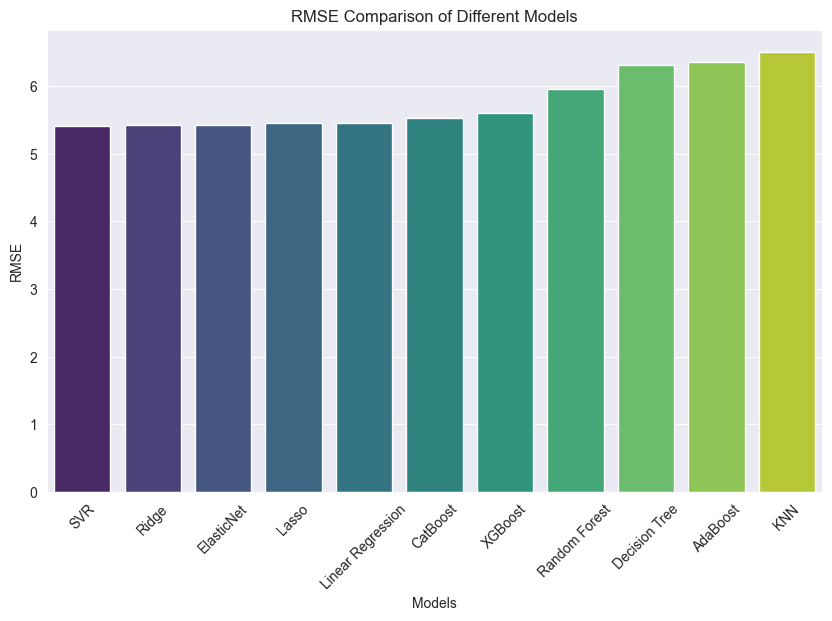

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_df,
    x=comparison_df.index,
    y="RMSE",
    palette="viridis"
)

plt.title("RMSE Comparison of Different Models")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.show()

In [18]:
results["SVR"]["Best Parameters"]

{'C': 0.5173957150270933,
 'epsilon': 0.9481699343853931,
 'kernel': 'linear',
 'gamma': 'scale'}

In [19]:
pipeline = results["SVR"]["Pipeline"]

In [20]:
y_pred = pipeline.predict(X_test)
print(root_mean_squared_error(y_test,y_pred))

5.349281194597471


In [21]:
best_model = min(
    results,
    key=lambda model: results[model]["Best RMSE"]
)

best_pipeline = results[best_model]["Pipeline"]

In [27]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_pipeline, "artifacts/model.pkl")

['artifacts/model.pkl']